In [ ]:
import torch
import datasets
import matplotlib.pyplot as plt

from model_loader import make_model, DEVICE

model = make_model(
    model_type="splitnet",
    channels="KP"
)
model.load_state_dict(torch.load(
    # "official_darcy/final/border_physics_limited_splitnet_attn_darcy_1p0_best_state.pt",
    # "baseline_full/final/border_splitnet_attn_baseline_full_nodarcy_best_state.pt",
    # "recent_analysis_unet/physics_tests/fixed/fixed_physics_limited_attn_unet_darcy_0p0_best_state.pt",
    # "official_darcy/final/border_physics_limited_splitnet_attn_darcy_5p0_best_state.pt",
    # "baseline_full/final/border_prof_unet_baseline_full_nodarcy_best_state.pt",
    # "baseline_full/final/border_unetfixed_baseline_full_nodarcy_best_state.pt",
    "limited_prior_tests2/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_best_state.pt",
    # "limited_prior_tests/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_best_state.pt",

    map_location=DEVICE
))

model.eval()

SplitNet(
  (K_encode): Encode(
    (c1): TwoConv(
      (seq): Sequential(
        (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (d1): Downsample(
      (conv): TwoConv(
        (seq): Sequential(
          (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU()
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, pad

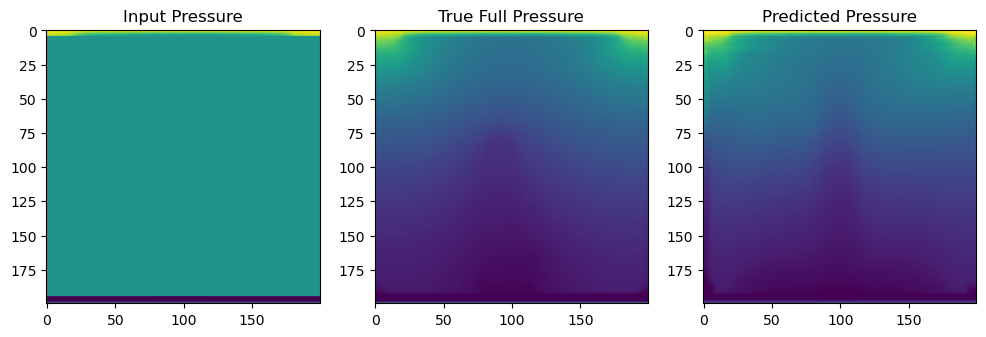

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import datasets
from model_loader import make_model, DEVICE, ChannelSelectDataset

val_sims = np.array([123])

base_dataset = datasets.BorderDenseDatasetFull(
    sims=val_sims,
    channels="KP"
)

dataset = ChannelSelectDataset(base_dataset, channels="KP")
num = 55
feat, label = dataset[num]
# feat, label, msk = dataset[num]

with torch.no_grad():
    pred = model(feat.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[1].cpu())
plt.title("Input Pressure")

plt.subplot(1,3,2)
plt.imshow(label[1].cpu())
plt.title("True Full Pressure")

plt.subplot(1,3,3)
plt.imshow(pred[1])
plt.title("Predicted Pressure")

plt.show()

In [17]:
for name, x in [
    ("feat K", feat[0]),
    ("feat P", feat[1]),
    ("label K", label[0]),
    ("label P", label[1]),
    ("pred K", pred[0]),
    ("pred P", pred[1]),
]:
    print(name, x.min().item(), x.max().item(), x.mean().item())

feat K -1.0 0.0 -0.010666992515325546
feat P -1.0 0.9296875 -0.009687500074505806
label K -1.0 -0.0625 -0.17101289331912994
label P -1.0 0.9296875 -0.5445789098739624
pred K -0.9999998211860657 -0.04393785446882248 -0.16034160554409027
pred P -1.0 0.8745688199996948 -0.5295157432556152


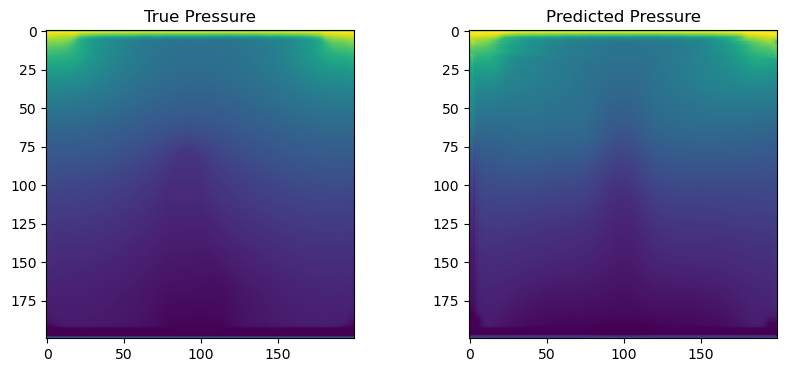

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(label[1].cpu())
plt.title("True Pressure")

plt.subplot(1, 2, 2)
plt.imshow(pred[1])
plt.title("Predicted Pressure")

plt.show()

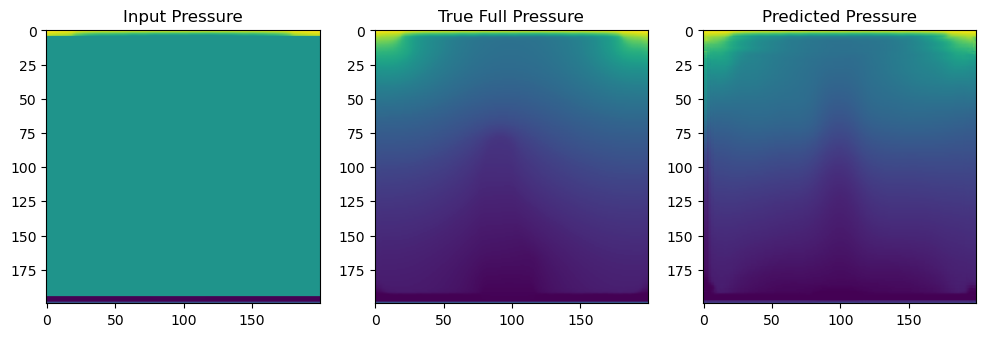

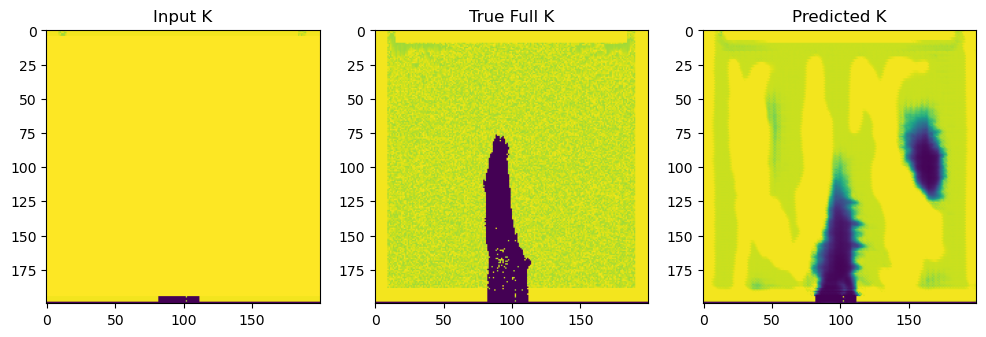

In [19]:
true_p = label[1].cpu()
pred_p = pred[1].cpu()

vmin = min(true_p.min().item(), pred_p.min().item())
vmax = max(true_p.max().item(), pred_p.max().item())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[1].cpu(), vmin=vmin, vmax=vmax)
plt.title("Input Pressure")

plt.subplot(1,3,2)
plt.imshow(true_p, vmin=vmin, vmax=vmax)
plt.title("True Full Pressure")

plt.subplot(1,3,3)
plt.imshow(pred_p, vmin=vmin, vmax=vmax)
plt.title("Predicted Pressure")

plt.show()


true_k = label[0].cpu()
pred_k = pred[0].cpu()

vmin = min(true_k.min().item(), pred_k.min().item())
vmax = max(true_k.max().item(), pred_k.max().item())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[0].cpu(), vmin=vmin, vmax=vmax)
plt.title("Input K")

plt.subplot(1,3,2)
plt.imshow(true_k, vmin=vmin, vmax=vmax)
plt.title("True Full K")

plt.subplot(1,3,3)
plt.imshow(pred_k, vmin=vmin, vmax=vmax)
plt.title("Predicted K")

plt.show()